In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [69]:
df = pd.read_csv("data/MICRODADOS_ENEM_2020.csv", encoding="cp860", sep=";")

In [70]:
df = df.sample(2_000_000, random_state=42)
# I will consider the score in portuguese test
df["target"] = df["NU_NOTA_LC"]
df["TP_DEPENDENCIA_ADM_ESC"] = df["TP_DEPENDENCIA_ADM_ESC"].fillna(-1)

# put everyone above 50 years to the class of 50 years
df["TP_FAIXA_ETARIA"] = df["TP_FAIXA_ETARIA"].apply(lambda x : x if x < 16 else 15)

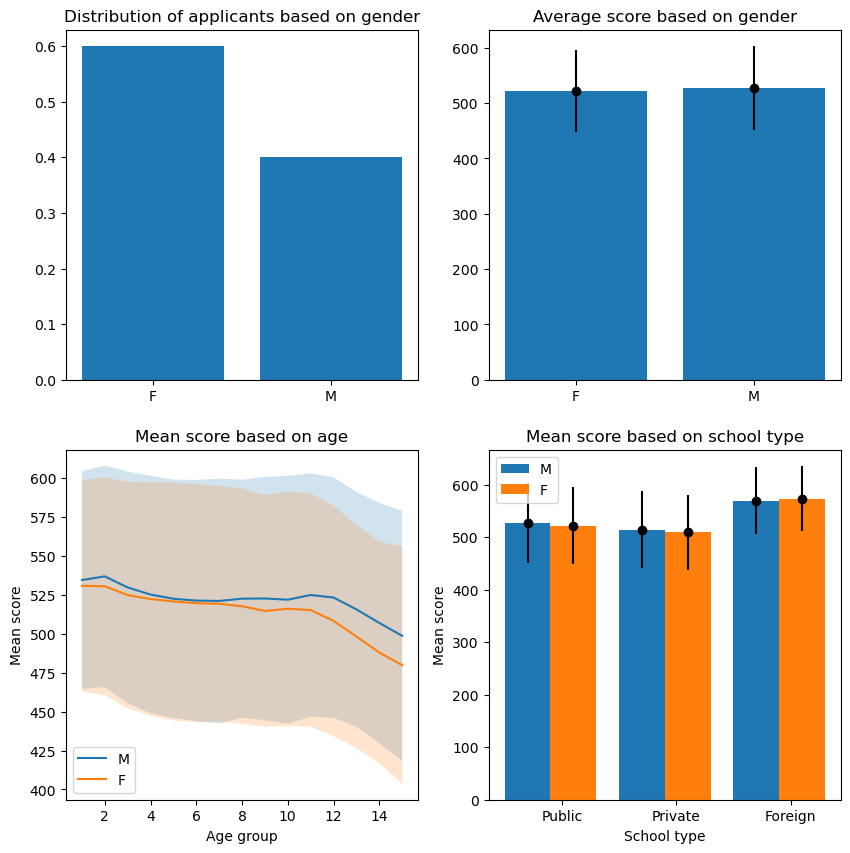

In [72]:

fig, axs = plt.subplots(nrows = 2, ncols = 2, figsize = (10, 10))

axs[0, 0].bar(
    [0, 1],
    df["TP_SEXO"].value_counts().values / df["TP_SEXO"].count(),
)
axs[0, 0].set_xticks([0, 1])
axs[0, 0].set_xticklabels(["F", "M"])
axs[0, 0].set_title("Distribution of applicants based on gender")


axs[0, 1].bar(
    [0, 1],
    df.groupby("TP_SEXO")["target"].mean().values
)
axs[0, 1].errorbar(
    [0, 1],
    df.groupby("TP_SEXO")["target"].mean().values,
    yerr=df.groupby("TP_SEXO")["target"].std().values,
    color="black",
    fmt="o",
)
axs[0, 1].set_xticks([0, 1])
axs[0, 1].set_xticklabels(["F", "M"])
axs[0, 1].set_title("Average score based on gender")



def simplify_age(age):
    return age // 4 * 4

#df["age"] = df["NU_IDADE"].apply(simplify_age)

for i in ["M", "F"]:
    df_filter = df[df["TP_SEXO"] == i]
    df_filter_mean = df_filter.groupby("TP_FAIXA_ETARIA")["target"].mean().reset_index()
    axs[1, 0].plot(
        df_filter_mean["TP_FAIXA_ETARIA"],
        df_filter_mean["target"],
        label=i,
    )

    df_filter_std = df_filter.groupby("TP_FAIXA_ETARIA")["target"].std().reset_index()
    axs[1, 0].fill_between(
        df_filter_mean["TP_FAIXA_ETARIA"],
        df_filter_mean["target"] - df_filter_std["target"],
        df_filter_mean["target"] + df_filter_std["target"],
        alpha=0.2,
    )


axs[1, 0].set_title("Mean score based on age")
axs[1, 0].set_xlabel("Age group")
axs[1, 0].set_ylabel("Mean score")
axs[1, 0].legend()

#df["COMBINED_SCHOOL"] = df["TP_ESCOLA"] * 10000 # + df["TP_DEPENDENCIA_ADM_ESC"]
df["COMBINED_SCHOOL"] = df["TP_ESCOLA"]

labels_school = ["Public", "Private", "Foreign"]
for i, g in enumerate(["M", "F"]):
    df_filter = df[df["TP_SEXO"] == g]
    unique_schools = df_filter["COMBINED_SCHOOL"].unique()
    axs[1, 1].bar(
        np.arange(len(unique_schools)) + i * 0.4 + 0.1,
        df_filter.groupby("COMBINED_SCHOOL")["target"].mean().values,
        width=0.4,
        label=g,
    )
    df_filter_std = df_filter.groupby("COMBINED_SCHOOL")["target"].std().values
    axs[1, 1].errorbar(
        np.arange(len(unique_schools)) + i * 0.4 + 0.1,
        df_filter.groupby("COMBINED_SCHOOL")["target"].mean().values,
        yerr=df_filter_std,
        color="black",
        fmt="o",
    )
axs[1, 1].set_xticks(np.arange(len(unique_schools)) + 0.4)
axs[1, 1].set_xticklabels(labels_school)
axs[1, 1].set_title("Mean score based on school type")
axs[1, 1].set_xlabel("School type")
axs[1, 1].set_ylabel("Mean score")
axs[1, 1].legend()

plt.show()


In [74]:
score_threshold = 500
# for each type of school
for school in sorted(df["COMBINED_SCHOOL"].unique()):
    # for each age category
    for age in sorted(df["TP_FAIXA_ETARIA"].unique()):
        df_filter = df[(df["COMBINED_SCHOOL"] == school) & (df["TP_FAIXA_ETARIA"] == age)]
        y = df_filter["target"].values > score_threshold
        print(f"P({school}, {age}) = {len(df_filter) / len(df) : .3f} \t P(y | {school}, {age}) = {y.mean():.3f}")



P(1, 1) =  0.055 	 P(y | 1, 1) = 0.500
P(1, 2) =  0.036 	 P(y | 1, 2) = 0.469
P(1, 3) =  0.061 	 P(y | 1, 3) = 0.414
P(1, 4) =  0.081 	 P(y | 1, 4) = 0.364
P(1, 5) =  0.071 	 P(y | 1, 5) = 0.304
P(1, 6) =  0.058 	 P(y | 1, 6) = 0.269
P(1, 7) =  0.046 	 P(y | 1, 7) = 0.244
P(1, 8) =  0.040 	 P(y | 1, 8) = 0.229
P(1, 9) =  0.034 	 P(y | 1, 9) = 0.212
P(1, 10) =  0.030 	 P(y | 1, 10) = 0.199
P(1, 11) =  0.097 	 P(y | 1, 11) = 0.190
P(1, 12) =  0.058 	 P(y | 1, 12) = 0.182
P(1, 13) =  0.040 	 P(y | 1, 13) = 0.171
P(1, 14) =  0.024 	 P(y | 1, 14) = 0.163
P(1, 15) =  0.028 	 P(y | 1, 15) = 0.158
P(2, 1) =  0.002 	 P(y | 2, 1) = 0.451
P(2, 2) =  0.077 	 P(y | 2, 2) = 0.446
P(2, 3) =  0.081 	 P(y | 2, 3) = 0.360
P(2, 4) =  0.023 	 P(y | 2, 4) = 0.223
P(2, 5) =  0.008 	 P(y | 2, 5) = 0.149
P(2, 6) =  0.003 	 P(y | 2, 6) = 0.101
P(2, 7) =  0.002 	 P(y | 2, 7) = 0.078
P(2, 8) =  0.001 	 P(y | 2, 8) = 0.074
P(2, 9) =  0.001 	 P(y | 2, 9) = 0.062
P(2, 10) =  0.001 	 P(y | 2, 10) = 0.071
P(2, 11) = 